In [ ]:
import os
os.chdir("/content/drive/MyDrive/kisco/Data")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
csv_data = pd.read_csv("fish_all.csv")
csv_data.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [ ]:
fish_all = csv_data[["Weight", "Length", "Diagonal", "Height", "Width"]]
fish_target = csv_data["Species"]
print(fish_all.shape, fish_target.shape)

(159, 5) (159,)


In [ ]:
from sklearn.model_selection import train_test_split
train_data, test_data, train_target, test_target = train_test_split(fish_all, fish_target, random_state=42)
print(train_data.shape, test_data.shape)

(119, 5) (40, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
train_scaled = ss.fit_transform(train_data)
test_scaled = ss.transform(test_data)

### 다항분류(SGD:확률적경사하강법)

In [ ]:
from sklearn.linear_model import SGDClassifier
sgd_model = SGDClassifier(loss="log_loss", max_iter=10, random_state=42)
sgd_model.fit(train_scaled, train_target)
print("훈련데이터의 정확도 : ", sgd_model.score(train_scaled, train_target))
print("테스트데이터의 정확도 : ", sgd_model.score(test_scaled, test_target))

훈련데이터의 정확도 :  0.773109243697479
테스트데이터의 정확도 :  0.775


/usr/local/lib/python3.9/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [ ]:
sgd_model.partial_fit(train_scaled, train_target)#partial_fit:모델을 이어서 훈련 계속
print(sgd_model.score(train_scaled, train_target))
print(sgd_model.score(test_scaled, test_target))

0.8151260504201681
0.8


In [ ]:
sgd_model = SGDClassifier(loss="log_loss", random_state=42)

train_score = []
test_score = []
classes = np.unique(train_target)

for _ in range(0, 300):
  sgd_model.partial_fit(train_scaled, train_target, classes=classes)
  train_score.append(sgd_model.score(train_scaled, train_target))
  test_score.append(sgd_model.score(test_scaled, test_target))

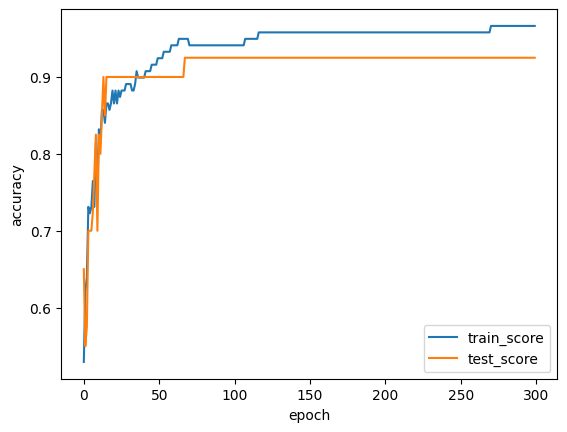

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_score)
plt.plot(test_score)
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend(["train_score", "test_score"])
plt.show()

In [ ]:
sgd_model = SGDClassifier(loss="log_loss", max_iter=100, tol=None, random_state=42)
sgd_model.fit(train_scaled, train_target)
print(sgd_model.score(train_scaled, train_target))
print(sgd_model.score(test_scaled, test_target))

0.957983193277311
0.925


In [ ]:
sgd_model = SGDClassifier(loss="hinge", max_iter=100, tol=None, random_state=42)#hinge = SVM
sgd_model.fit(train_scaled, train_target)
print(sgd_model.score(train_scaled, train_target))
print(sgd_model.score(test_scaled, test_target))

0.9495798319327731
0.925
